# MLOps Lab Worksheet - CNN on CIFAR-10

**Name:** Nisarg Upadhyay  
**Roll Number:** B23CS1075

## 1. Setup and Imports

In [1]:
# Install required packages
!pip install wandb ptflops -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
import wandb
from ptflops import get_model_complexity_info
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 2. Weights & Biases Initialization

In [3]:
# Login to W&B (you'll be prompted for API key on first run)
wandb.login()

# Initialize W&B project
wandb.init(
    project="MLOps-Assignment2-CIFAR10",
    name="SimpleCNN-30epochs",
    config={
        "model": "SimpleCNN",
        "dataset": "CIFAR-10",
        "epochs": 30,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "weight_decay": 1e-4
    }
)

config = wandb.config
print(f"W&B Run: {wandb.run.name}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: b23cs1075 (b23cs1075-indian-institute-of-technology-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B Run: SimpleCNN-30epochs


## 3. Custom CIFAR-10 DataLoader

In [4]:
class CustomCIFAR10Dataset(Dataset):
    """
    Custom Dataset wrapper for CIFAR-10 with configurable transforms.
    """
    def __init__(self, root='./data', train=True, transform=None, download=True):
        self.dataset = torchvision.datasets.CIFAR10(
            root=root,
            train=train,
            download=download,
            transform=None  # We apply transform manually
        )
        self.transform = transform
        self.classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck']

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_class_name(self, label):
        return self.classes[label]

In [5]:
# Define transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# Load datasets
full_train_dataset = CustomCIFAR10Dataset(root='./data', train=True,
                                           transform=train_transform, download=True)
test_dataset = CustomCIFAR10Dataset(root='./data', train=False,
                                     transform=test_transform, download=True)

# Split train into train and validation (80-10-10 split)
# Training set: 40000, Validation: 10000, Test: 10000
train_size = 40000
val_size = 10000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

# Create val dataset with test transforms (no augmentation)
val_dataset.dataset = CustomCIFAR10Dataset(root='./data', train=True,
                                            transform=test_transform, download=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:10<00:00, 16.1MB/s]


Training samples: 40000
Validation samples: 10000
Test samples: 10000


In [6]:
# Create DataLoaders
BATCH_SIZE = config.batch_size

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 128
Training batches: 313
Validation batches: 79
Test batches: 79


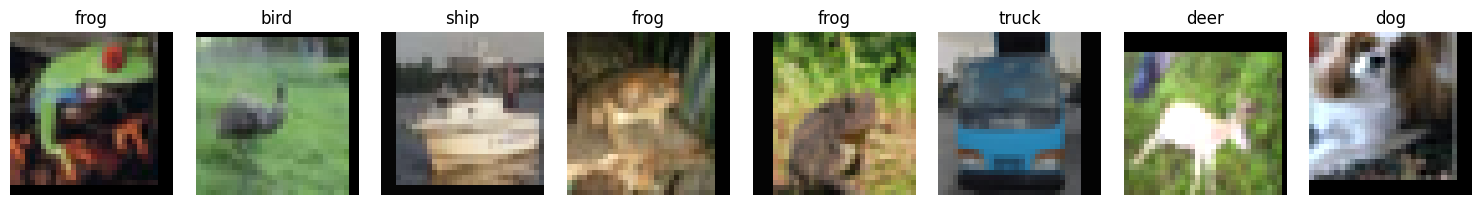

In [7]:
# Visualize sample images
def show_samples(dataset, num_samples=8):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))

    # Denormalize for visualization
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    for i in range(num_samples):
        img, label = dataset[i]
        img = img * std + mean  # Denormalize
        img = img.numpy().transpose(1, 2, 0)
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(full_train_dataset.classes[label])
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    wandb.log({"sample_images": wandb.Image('sample_images.png')})
    plt.show()

show_samples(train_dataset)

## 4. SimpleCNN Model Definition

In [8]:
class SimpleCNN(nn.Module):
    """
    Simple CNN architecture for CIFAR-10 classification.
    3 convolutional blocks followed by fully connected layers.
    ~500K parameters for fast training.
    """
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Conv Block 1: 3 -> 32 channels
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv Block 2: 32 -> 64 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Conv Block 3: 64 -> 128 channels
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Block 1: 32x32 -> 16x16
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Block 2: 16x16 -> 8x8
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Block 3: 8x8 -> 4x4
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten and FC layers
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [9]:
# Initialize model
model = SimpleCNN(num_classes=10).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel Architecture:")
print(model)

Total parameters: 620,810
Trainable parameters: 620,810

Model Architecture:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
)


## 5. FLOPs Calculation

In [10]:
# Calculate FLOPs using ptflops
macs, params = get_model_complexity_info(
    model,
    (3, 32, 32),  # CIFAR-10 input size
    as_strings=True,
    print_per_layer_stat=True,
    verbose=True
)

print(f"\n{'='*50}")
print(f"Model Complexity Summary")
print(f"{'='*50}")
print(f"Computational complexity (MACs): {macs}")
print(f"Number of parameters: {params}")

# Log to W&B
wandb.config.update({
    "MACs": macs,
    "Parameters": params,
    "Total_Params": total_params
})

SimpleCNN(
  620.81 k, 100.000% Params, 11.08 MMac, 98.973% MACs, 
  (conv1): Conv2d(896, 0.144% Params, 917.5 KMac, 8.197% MACs, 3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, 0.010% Params, 65.54 KMac, 0.585% MACs, 32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(18.5 k, 2.979% Params, 4.73 MMac, 42.302% MACs, 32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, 0.021% Params, 32.77 KMac, 0.293% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(73.86 k, 11.897% Params, 4.73 MMac, 42.228% MACs, 64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, 0.041% Params, 16.38 KMac, 0.146% MACs, 128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(524.54 k, 84.493% Params, 524.54 KMac, 4.686% MACs, in_features=2048, out_features=256, bias=True)
  (fc2): Linear(2.57 k, 0.414% Params, 2.5

## 6. Gradient Flow Visualization Functions

In [11]:
def plot_gradient_flow(named_parameters, epoch):
    """
    Plots the gradients flowing through different layers in the net during training.
    Can be used for checking for vanishing/exploding gradients.
    """
    ave_grads = []
    max_grads = []
    layers = []

    for n, p in named_parameters:
        if p.requires_grad and p.grad is not None:
            layers.append(n.replace('.weight', '').replace('.bias', ''))
            ave_grads.append(p.grad.abs().mean().cpu().item())
            max_grads.append(p.grad.abs().max().cpu().item())

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(layers))
    width = 0.35

    bars1 = ax.bar(x - width/2, max_grads, width, label='Max Gradient', color='#4facfe', alpha=0.8)
    bars2 = ax.bar(x + width/2, ave_grads, width, label='Avg Gradient', color='#00f2fe', alpha=0.8)

    ax.set_xlabel('Layers')
    ax.set_ylabel('Gradient Magnitude')
    ax.set_title(f'Gradient Flow - Epoch {epoch}')
    ax.set_xticks(x)
    ax.set_xticklabels(layers, rotation=45, ha='right')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'gradient_flow_epoch_{epoch}.png', dpi=150, bbox_inches='tight')
    wandb.log({f"gradient_flow": wandb.Image(f'gradient_flow_epoch_{epoch}.png')}, step=epoch)
    plt.show()
    plt.close()

    return ave_grads, max_grads, layers

In [12]:
def log_weight_histograms(model, epoch):
    """
    Log weight histograms for each layer to W&B.
    """
    for name, param in model.named_parameters():
        if param.requires_grad:
            wandb.log({
                f"weights/{name}": wandb.Histogram(param.data.cpu().numpy().flatten())
            }, step=epoch)

            if param.grad is not None:
                wandb.log({
                    f"gradients/{name}": wandb.Histogram(param.grad.cpu().numpy().flatten())
                }, step=epoch)

In [13]:
class WeightUpdateTracker:
    """
    Track weight updates between epochs to visualize learning dynamics.
    """
    def __init__(self, model):
        self.previous_weights = {}
        self.update_history = {}
        self._save_weights(model)

    def _save_weights(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.previous_weights[name] = param.data.clone()

    def compute_updates(self, model, epoch):
        updates = {}
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.previous_weights:
                update = (param.data - self.previous_weights[name]).abs()
                updates[name] = {
                    'mean': update.mean().item(),
                    'max': update.max().item(),
                    'std': update.std().item()
                }

                # Log histogram of weight updates
                wandb.log({
                    f"weight_updates/{name}": wandb.Histogram(update.cpu().numpy().flatten())
                }, step=epoch)

        self._save_weights(model)
        return updates

    def plot_update_magnitudes(self, updates, epoch):
        layers = list(updates.keys())
        means = [updates[l]['mean'] for l in layers]

        fig, ax = plt.subplots(figsize=(12, 5))
        bars = ax.bar(range(len(layers)), means, color='#667eea', alpha=0.8)

        ax.set_xlabel('Layers')
        ax.set_ylabel('Mean Weight Update Magnitude')
        ax.set_title(f'Weight Update Magnitudes - Epoch {epoch}')
        ax.set_xticks(range(len(layers)))
        ax.set_xticklabels([l.replace('.weight', '').replace('.bias', '') for l in layers],
                          rotation=45, ha='right')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'weight_updates_epoch_{epoch}.png', dpi=150, bbox_inches='tight')
        wandb.log({f"weight_update_plot": wandb.Image(f'weight_updates_epoch_{epoch}.png')}, step=epoch)
        plt.show()
        plt.close()

## 7. Training Functions

In [14]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total

    return val_loss, val_acc

## 8. Training Loop with Visualization

In [15]:
# Training configuration
EPOCHS = config.epochs
LEARNING_RATE = config.learning_rate

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=config.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Initialize weight tracker
weight_tracker = WeightUpdateTracker(model)

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
print(f"Starting training for {EPOCHS} epochs...")
print(f"{'='*70}")

Starting training for 30 epochs...



[Epoch 1] Generating gradient and weight visualizations...


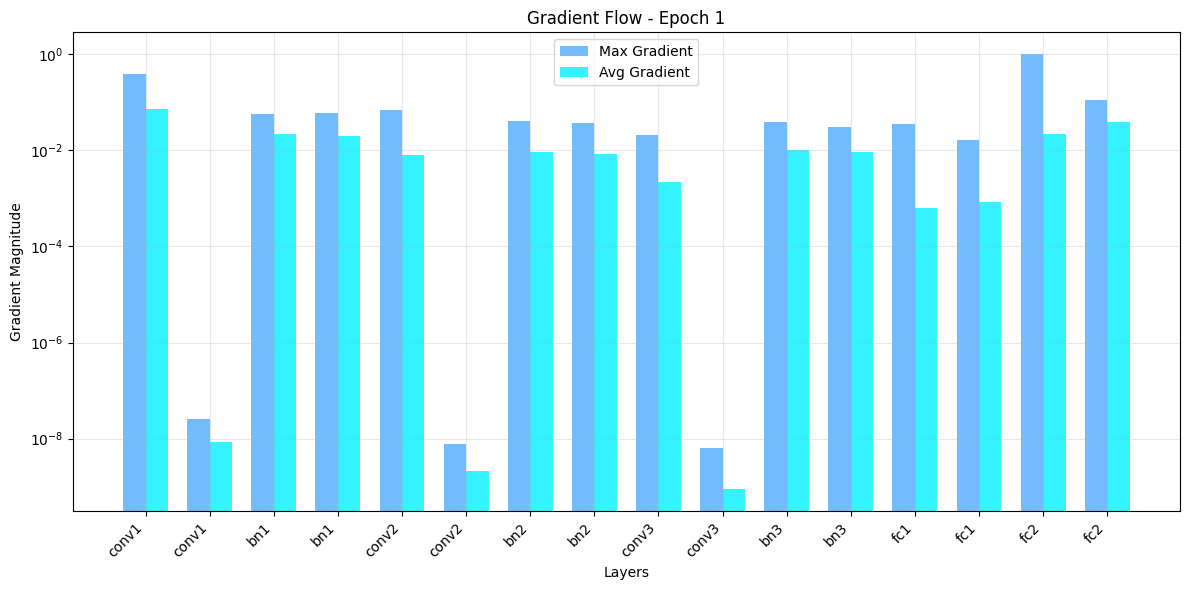

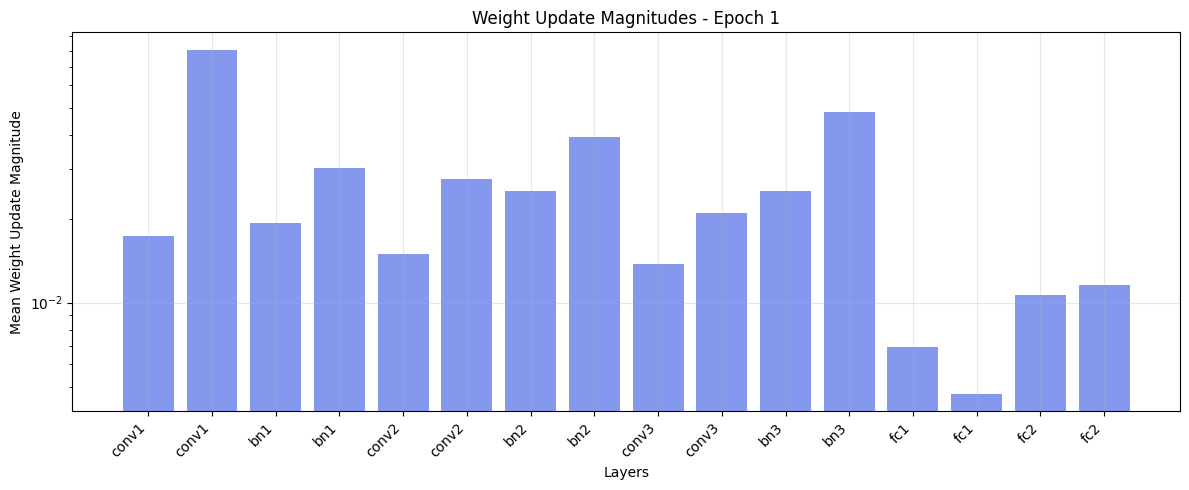

Epoch 01/30 | Train Loss: 1.6727 | Train Acc: 37.83% | Val Loss: 1.3709 | Val Acc: 49.57% | LR: 0.001000
  -> New best model saved! (Val Acc: 49.57%)
Epoch 02/30 | Train Loss: 1.3535 | Train Acc: 50.88% | Val Loss: 1.0711 | Val Acc: 60.63% | LR: 0.000997
  -> New best model saved! (Val Acc: 60.63%)
Epoch 03/30 | Train Loss: 1.2082 | Train Acc: 56.36% | Val Loss: 0.9683 | Val Acc: 65.24% | LR: 0.000989
  -> New best model saved! (Val Acc: 65.24%)
Epoch 04/30 | Train Loss: 1.1340 | Train Acc: 59.72% | Val Loss: 1.0471 | Val Acc: 63.23% | LR: 0.000976

[Epoch 5] Generating gradient and weight visualizations...


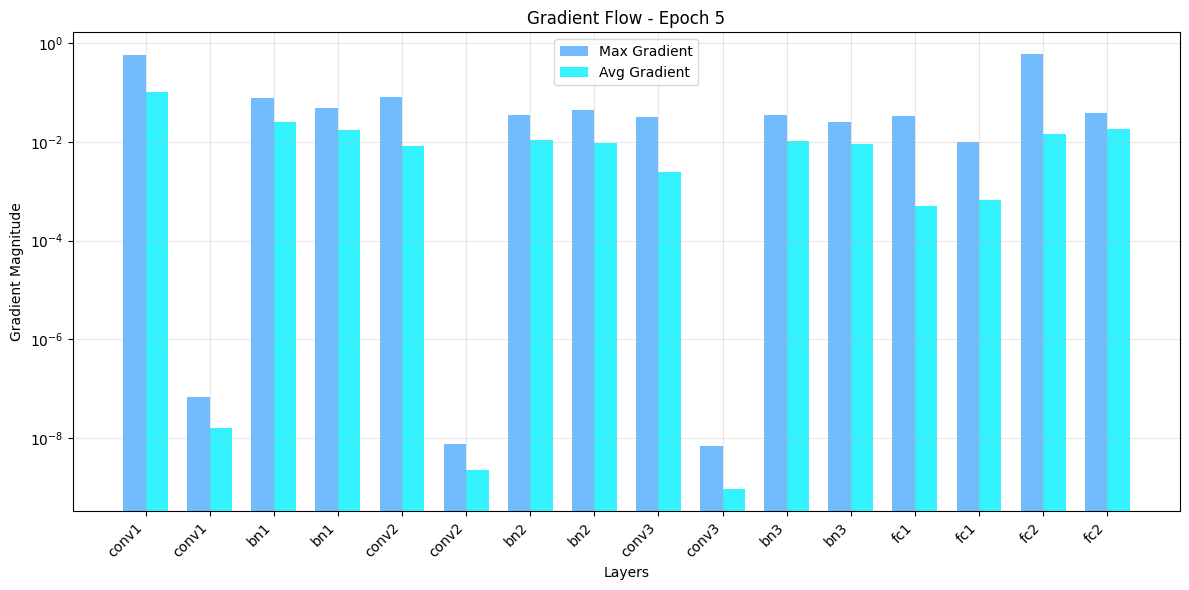

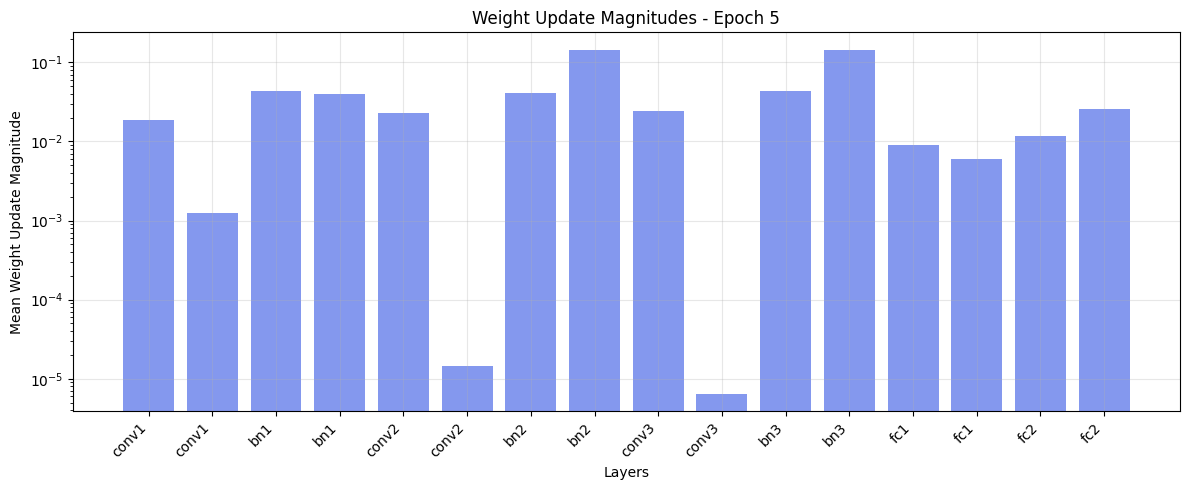

Epoch 05/30 | Train Loss: 1.0819 | Train Acc: 61.72% | Val Loss: 0.8424 | Val Acc: 70.22% | LR: 0.000957
  -> New best model saved! (Val Acc: 70.22%)
Epoch 06/30 | Train Loss: 1.0267 | Train Acc: 63.94% | Val Loss: 0.8435 | Val Acc: 70.06% | LR: 0.000933
Epoch 07/30 | Train Loss: 0.9822 | Train Acc: 65.52% | Val Loss: 0.7704 | Val Acc: 72.58% | LR: 0.000905
  -> New best model saved! (Val Acc: 72.58%)
Epoch 08/30 | Train Loss: 0.9533 | Train Acc: 66.42% | Val Loss: 0.7936 | Val Acc: 71.56% | LR: 0.000872
Epoch 09/30 | Train Loss: 0.9333 | Train Acc: 67.39% | Val Loss: 0.7325 | Val Acc: 74.09% | LR: 0.000835
  -> New best model saved! (Val Acc: 74.09%)

[Epoch 10] Generating gradient and weight visualizations...


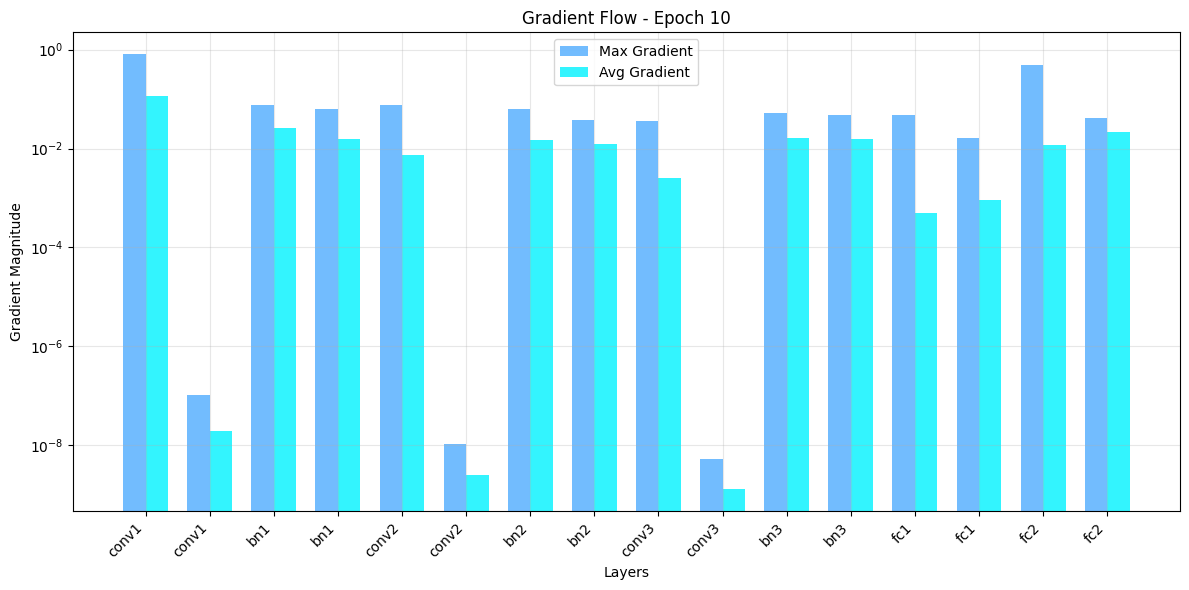

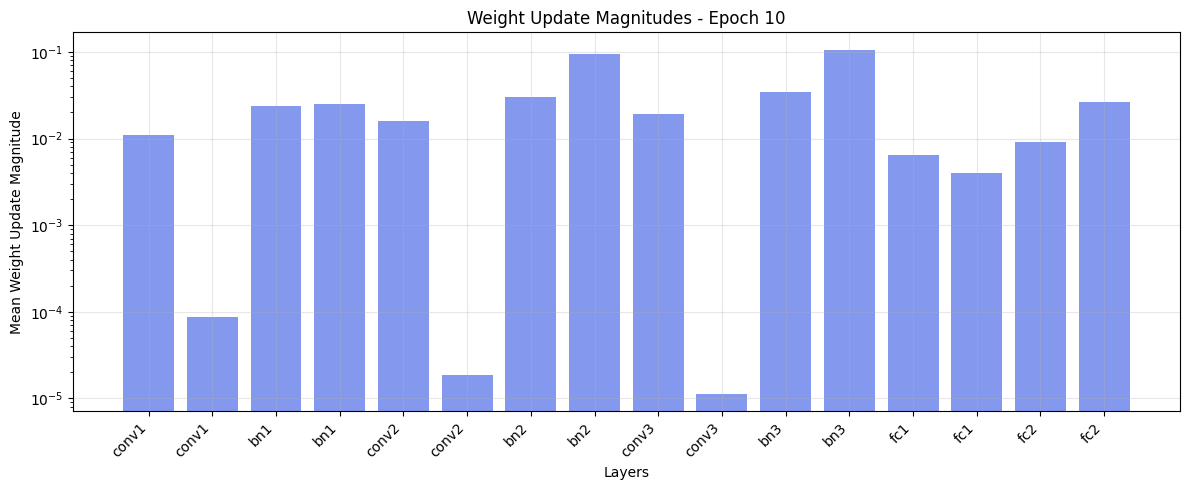

Epoch 10/30 | Train Loss: 0.9048 | Train Acc: 68.41% | Val Loss: 0.7240 | Val Acc: 74.16% | LR: 0.000794
  -> New best model saved! (Val Acc: 74.16%)
Epoch 11/30 | Train Loss: 0.8815 | Train Acc: 69.24% | Val Loss: 0.7038 | Val Acc: 75.14% | LR: 0.000750
  -> New best model saved! (Val Acc: 75.14%)
Epoch 12/30 | Train Loss: 0.8496 | Train Acc: 70.53% | Val Loss: 0.6702 | Val Acc: 75.94% | LR: 0.000703
  -> New best model saved! (Val Acc: 75.94%)
Epoch 13/30 | Train Loss: 0.8320 | Train Acc: 71.18% | Val Loss: 0.6553 | Val Acc: 76.58% | LR: 0.000655
  -> New best model saved! (Val Acc: 76.58%)
Epoch 14/30 | Train Loss: 0.8123 | Train Acc: 72.02% | Val Loss: 0.6643 | Val Acc: 76.83% | LR: 0.000604
  -> New best model saved! (Val Acc: 76.83%)

[Epoch 15] Generating gradient and weight visualizations...


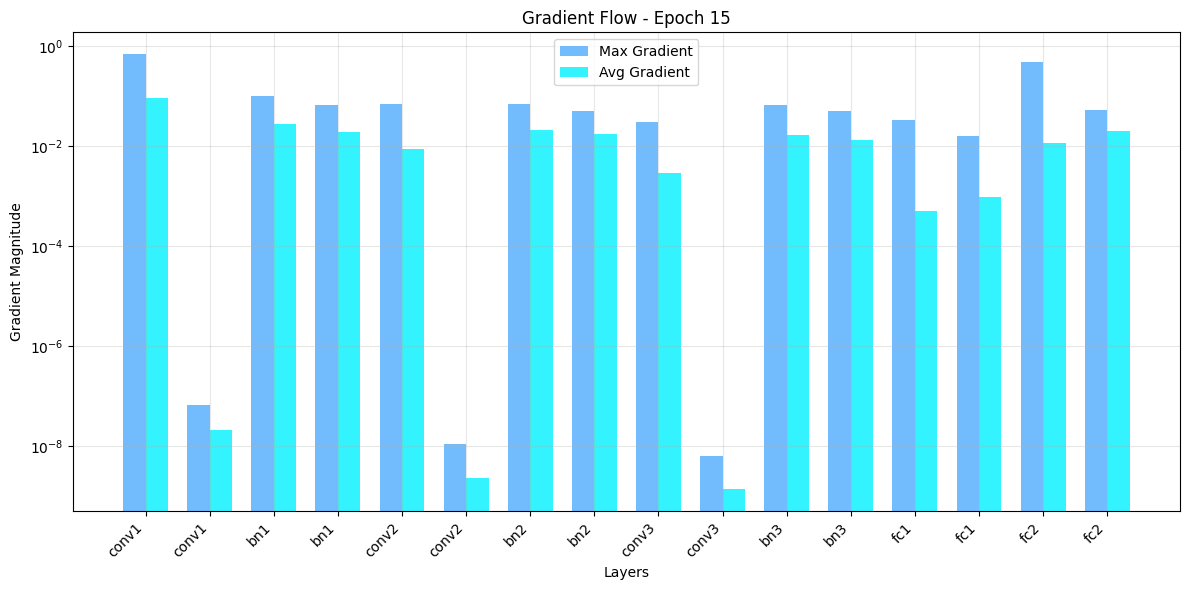

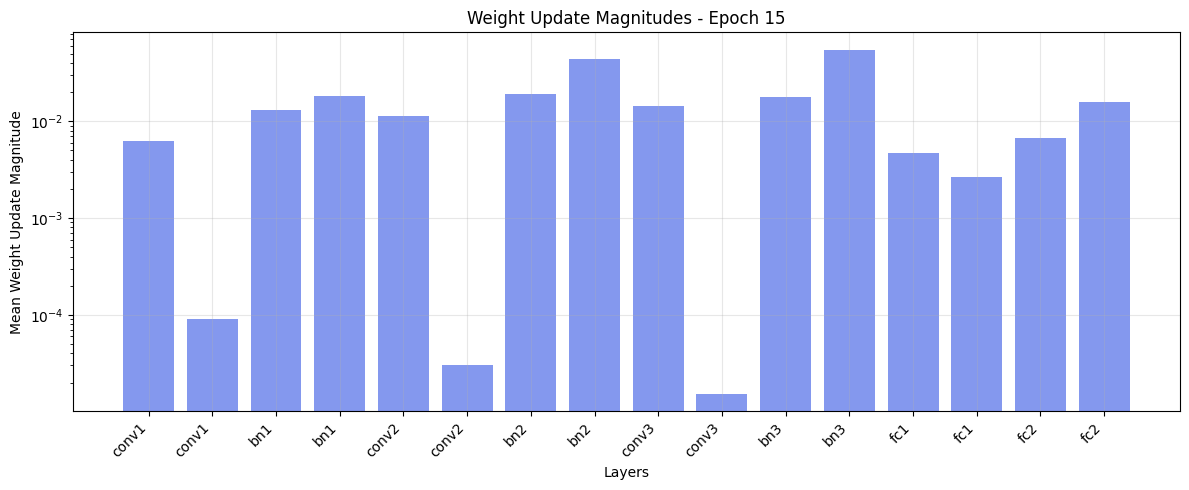

Epoch 15/30 | Train Loss: 0.7910 | Train Acc: 72.68% | Val Loss: 0.6394 | Val Acc: 77.49% | LR: 0.000552
  -> New best model saved! (Val Acc: 77.49%)
Epoch 16/30 | Train Loss: 0.7745 | Train Acc: 73.31% | Val Loss: 0.6183 | Val Acc: 78.22% | LR: 0.000500
  -> New best model saved! (Val Acc: 78.22%)
Epoch 17/30 | Train Loss: 0.7511 | Train Acc: 74.07% | Val Loss: 0.5920 | Val Acc: 78.84% | LR: 0.000448
  -> New best model saved! (Val Acc: 78.84%)
Epoch 18/30 | Train Loss: 0.7340 | Train Acc: 74.78% | Val Loss: 0.5877 | Val Acc: 79.40% | LR: 0.000396
  -> New best model saved! (Val Acc: 79.40%)
Epoch 19/30 | Train Loss: 0.7161 | Train Acc: 75.43% | Val Loss: 0.5729 | Val Acc: 79.82% | LR: 0.000345
  -> New best model saved! (Val Acc: 79.82%)

[Epoch 20] Generating gradient and weight visualizations...


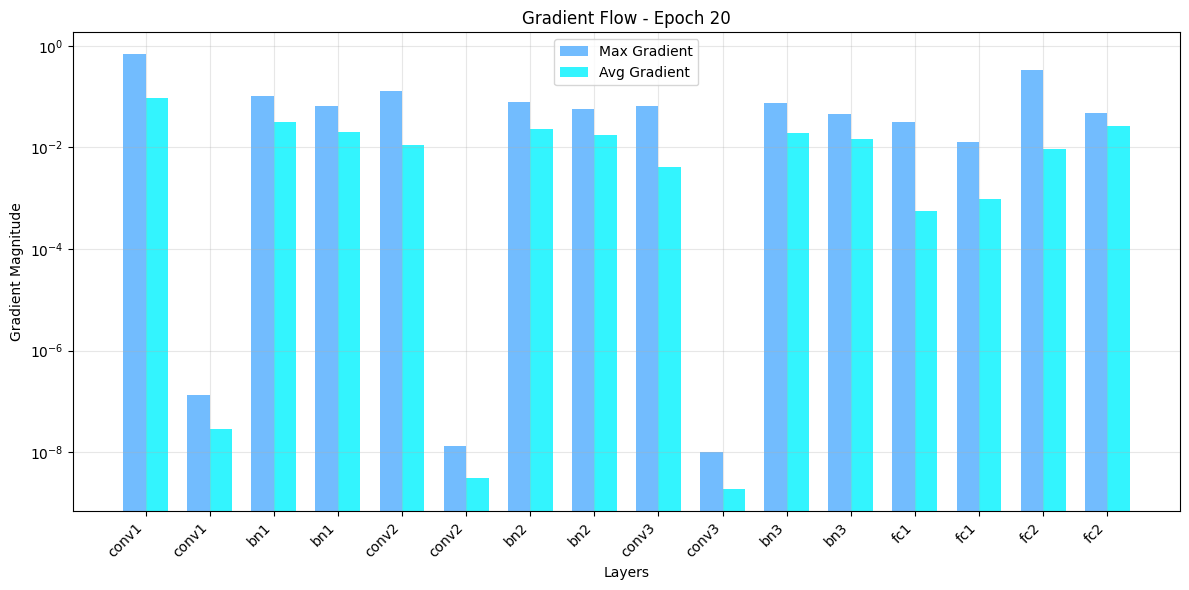

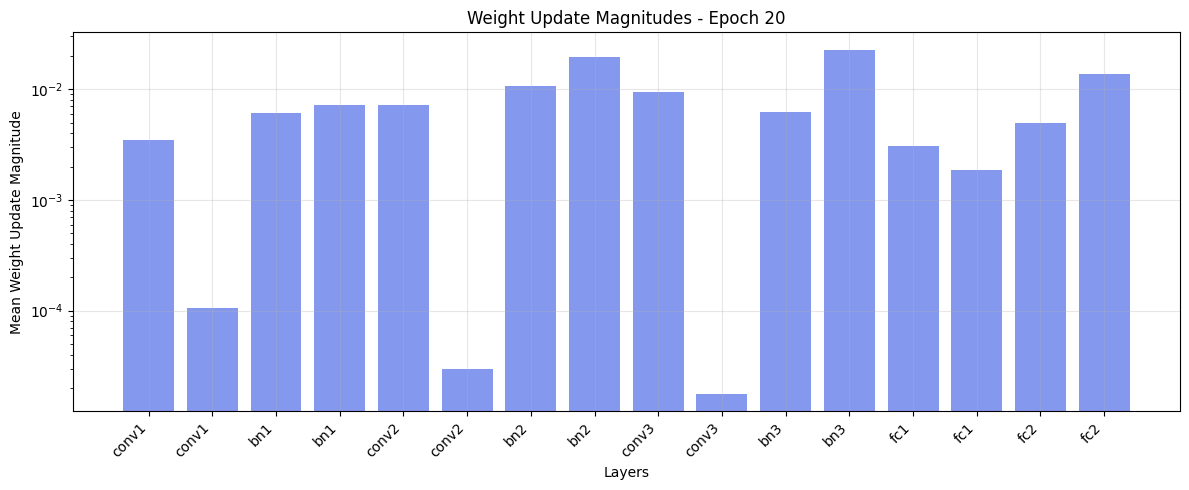

Epoch 20/30 | Train Loss: 0.7072 | Train Acc: 75.81% | Val Loss: 0.5677 | Val Acc: 79.86% | LR: 0.000297
  -> New best model saved! (Val Acc: 79.86%)
Epoch 21/30 | Train Loss: 0.6907 | Train Acc: 76.17% | Val Loss: 0.5604 | Val Acc: 80.14% | LR: 0.000250
  -> New best model saved! (Val Acc: 80.14%)
Epoch 22/30 | Train Loss: 0.6738 | Train Acc: 76.84% | Val Loss: 0.5658 | Val Acc: 79.75% | LR: 0.000206
Epoch 23/30 | Train Loss: 0.6712 | Train Acc: 77.03% | Val Loss: 0.5489 | Val Acc: 80.68% | LR: 0.000165
  -> New best model saved! (Val Acc: 80.68%)
Epoch 24/30 | Train Loss: 0.6607 | Train Acc: 77.39% | Val Loss: 0.5393 | Val Acc: 81.03% | LR: 0.000128
  -> New best model saved! (Val Acc: 81.03%)

[Epoch 25] Generating gradient and weight visualizations...


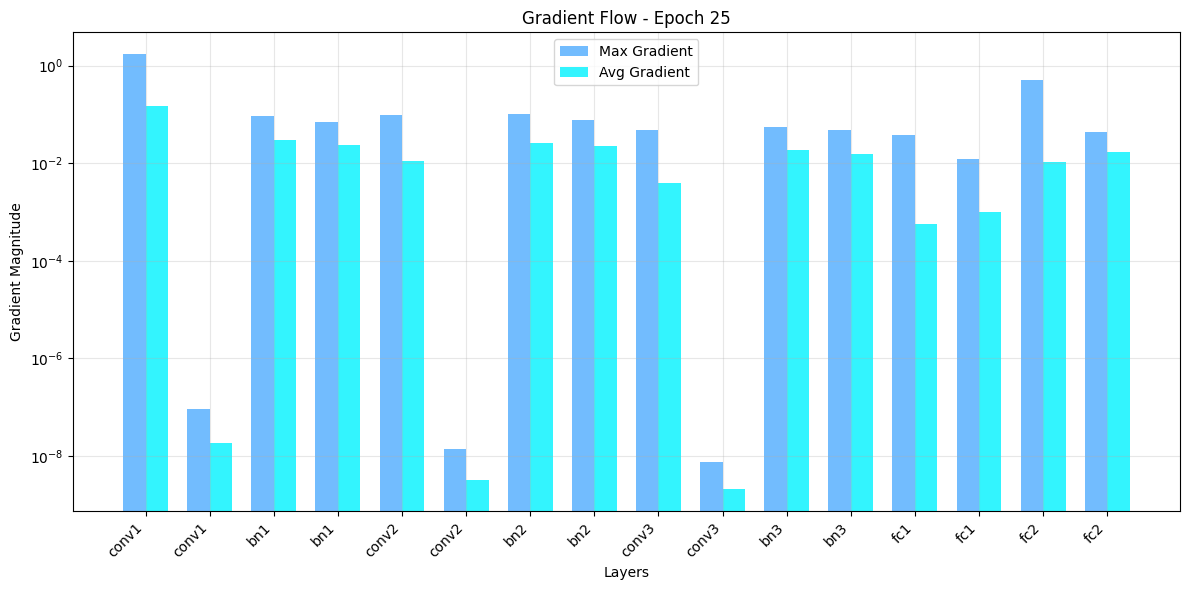

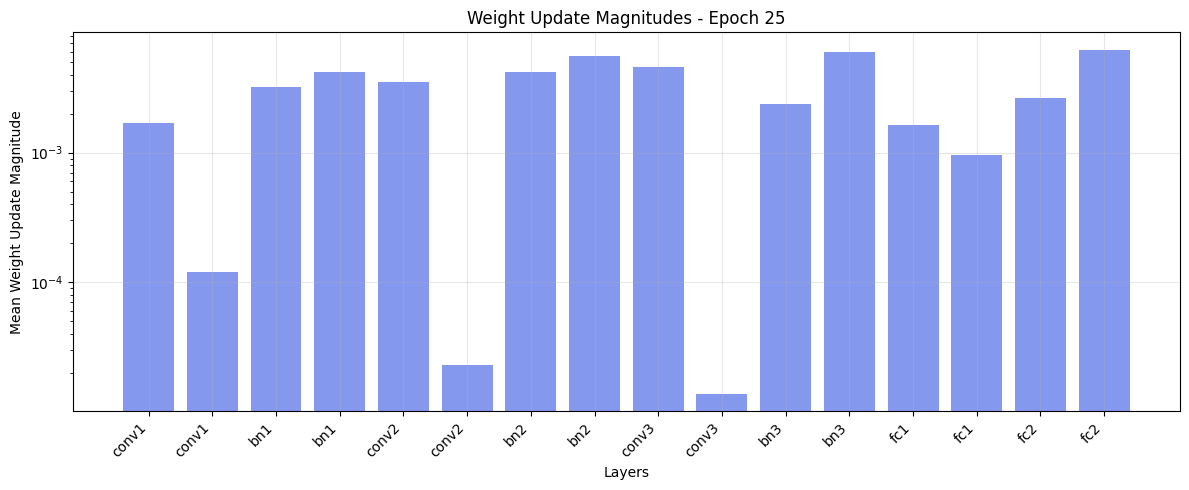

Epoch 25/30 | Train Loss: 0.6472 | Train Acc: 77.72% | Val Loss: 0.5327 | Val Acc: 81.30% | LR: 0.000095
  -> New best model saved! (Val Acc: 81.30%)
Epoch 26/30 | Train Loss: 0.6429 | Train Acc: 77.75% | Val Loss: 0.5415 | Val Acc: 80.99% | LR: 0.000067
Epoch 27/30 | Train Loss: 0.6348 | Train Acc: 78.30% | Val Loss: 0.5302 | Val Acc: 81.41% | LR: 0.000043
  -> New best model saved! (Val Acc: 81.41%)
Epoch 28/30 | Train Loss: 0.6310 | Train Acc: 78.39% | Val Loss: 0.5279 | Val Acc: 81.49% | LR: 0.000024
  -> New best model saved! (Val Acc: 81.49%)
Epoch 29/30 | Train Loss: 0.6367 | Train Acc: 78.04% | Val Loss: 0.5280 | Val Acc: 81.36% | LR: 0.000011

[Epoch 30] Generating gradient and weight visualizations...


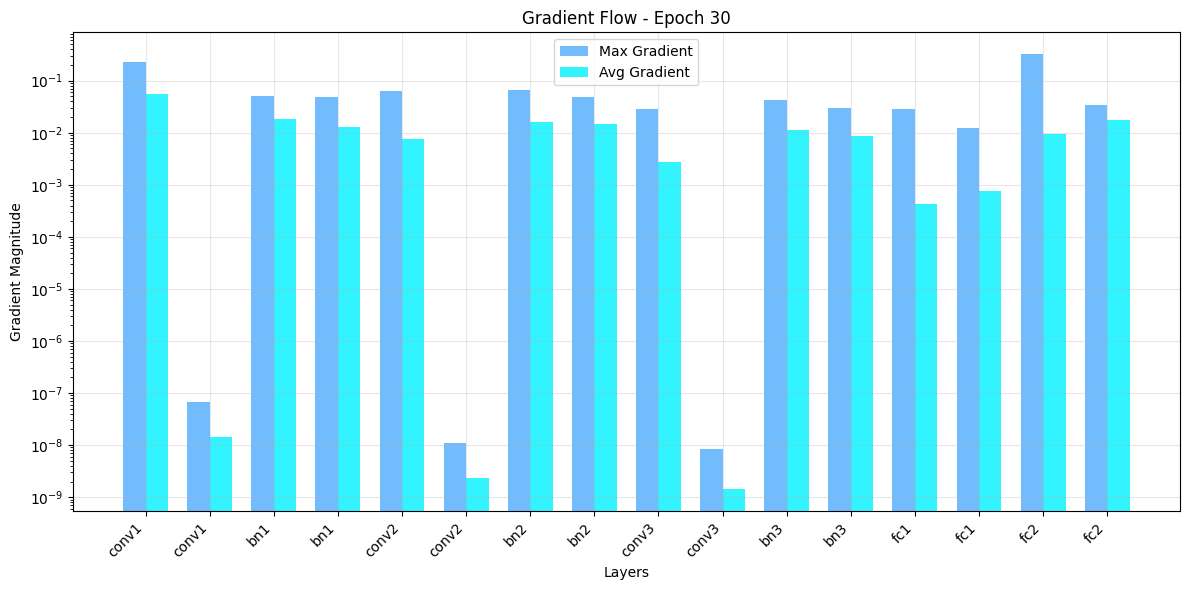

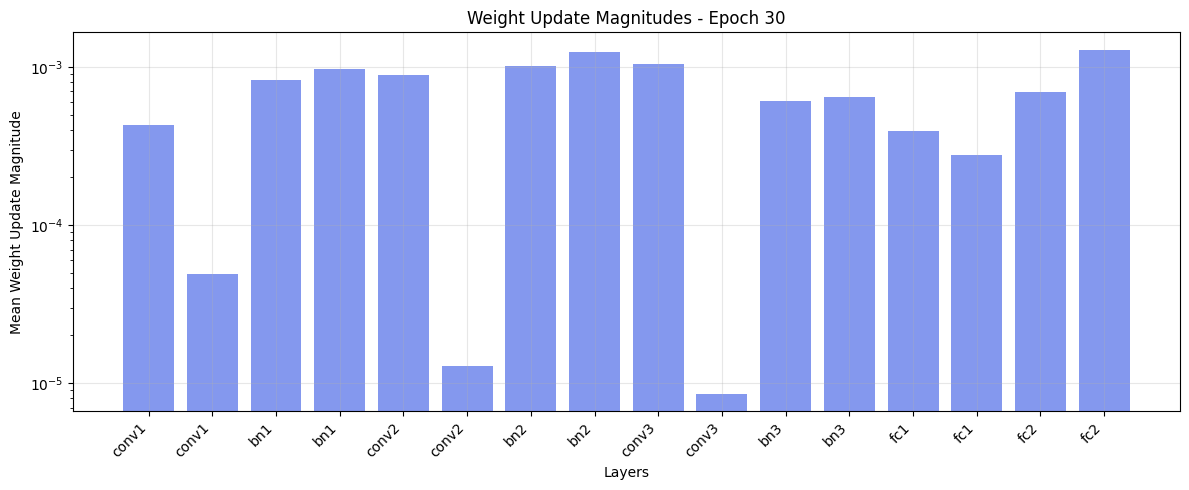

Epoch 30/30 | Train Loss: 0.6240 | Train Acc: 78.60% | Val Loss: 0.5277 | Val Acc: 81.46% | LR: 0.000003

Training completed! Best validation accuracy: 81.49%


In [16]:
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Log to W&B
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "learning_rate": current_lr
    }, step=epoch)

    # Visualize gradients and weights every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"\n[Epoch {epoch}] Generating gradient and weight visualizations...")

        # Gradient flow visualization
        plot_gradient_flow(model.named_parameters(), epoch)

        # Weight histograms
        log_weight_histograms(model, epoch)

        # Weight update tracking
        updates = weight_tracker.compute_updates(model, epoch)
        weight_tracker.plot_update_magnitudes(updates, epoch)

    # Print progress
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {current_lr:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> New best model saved! (Val Acc: {val_acc:.2f}%)")

print(f"\n{'='*70}")
print(f"Training completed! Best validation accuracy: {best_val_acc:.2f}%")

## 9. Final Test Evaluation

In [17]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")

wandb.log({
    "test_loss": test_loss,
    "test_acc": test_acc,
    "best_val_acc": best_val_acc
})

wandb.run.summary["best_val_acc"] = best_val_acc
wandb.run.summary["test_acc"] = test_acc


Test Results:
  Test Loss: 0.5431
  Test Accuracy: 81.21%


## 10. Training Curves Visualization

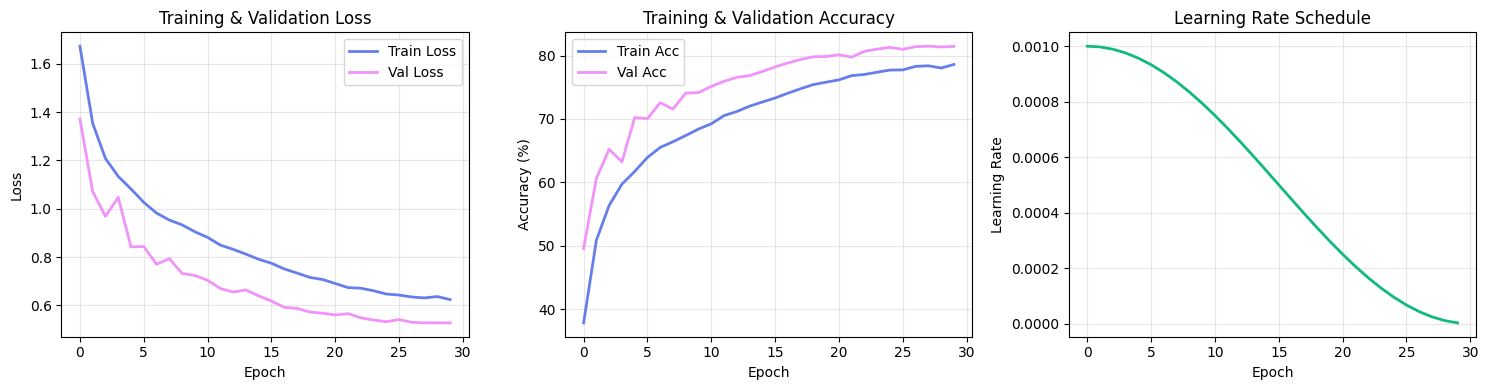

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', color='#667eea', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', color='#f093fb', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Acc', color='#667eea', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', color='#f093fb', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], color='#10b981', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
wandb.log({"training_curves": wandb.Image('training_curves.png')})
plt.show()

In [20]:
# Finish W&B run
wandb.finish()
print("\nW&B run completed. Check your dashboard for all visualizations!")

best_val_acc,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
test_acc,▁
test_loss,▁
train_acc,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███████████
train_loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▆▅▆▆▆▆▇▇▇▇▇▇▇█████████████
val_loss,█▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
MACs,11.19 MMac
best_val_acc,81.49



W&B run completed. Check your dashboard for all visualizations!
